In [3]:
import pandas as pd
import numpy as np

data = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = data["X"]

df = pd.DataFrame(X_full, columns=[f"F{i}" for i in range(30)])

corr = df.corr().abs()

In [4]:
distance = 1 - corr

In [20]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

condensed_distance = squareform(distance)
Z = linkage(condensed_distance, method='average')

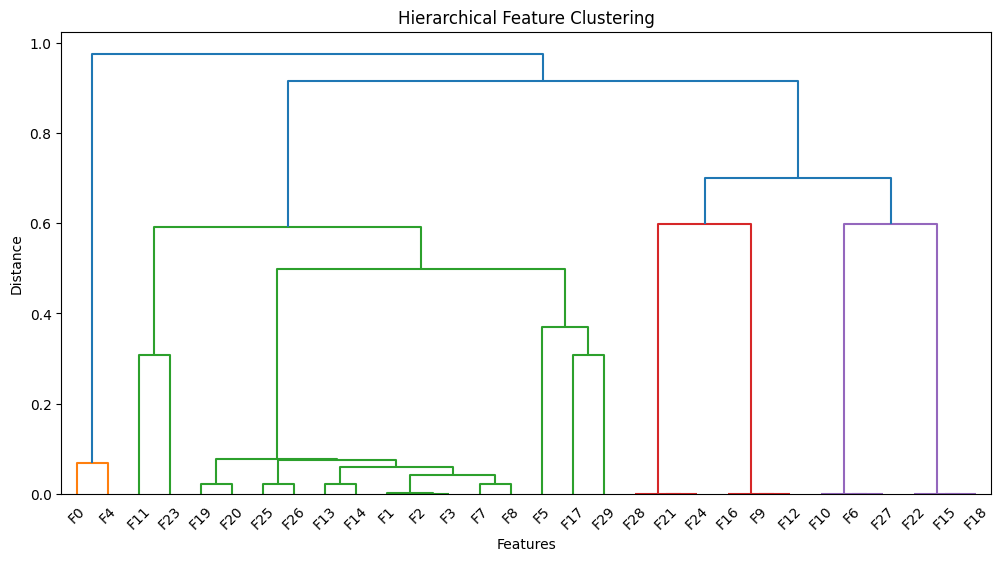

In [21]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12,6))

dendrogram(Z, labels=df.columns)

plt.title("Hierarchical Feature Clustering")
plt.xlabel("Features")
plt.ylabel("Distance")

plt.show()

In [16]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=0.3, criterion='distance')

In [17]:
feature_clusters = {}

for feature, cluster in zip(df.columns, clusters):
    feature_clusters.setdefault(cluster, []).append(feature)

print(feature_clusters)

{np.int32(1): ['F0', 'F4'], np.int32(4): ['F1', 'F2', 'F3', 'F7', 'F8', 'F13', 'F14', 'F19', 'F20', 'F25', 'F26'], np.int32(7): ['F5'], np.int32(10): ['F6', 'F10', 'F27'], np.int32(9): ['F9', 'F12', 'F16'], np.int32(2): ['F11'], np.int32(11): ['F15', 'F18', 'F22'], np.int32(5): ['F17'], np.int32(8): ['F21', 'F24', 'F28'], np.int32(3): ['F23'], np.int32(6): ['F29']}
